# A Privacy-Safe Manhattan Course Mental Map

**Mapping Systems — Assignment 02: Geoprocessing**<br>
**Research question:** What does each public Manhattan course anchor inherit from its surrounding rent geography and nearest transit infrastructure?

## tl;dr

Six public course-life anchors are represented at public-site or intersection precision. Every point is projected to **EPSG:2263**, joined to its containing Neighborhood Tabulation Area, and related to the nearest StreetEasy rent-reporting representative point and subway station. The executed result preserves **6 of 6** places, has no missing joins, and returns a privacy-safe **EPSG:4326** GeoJSON.

The places are real public anchors found in the author's course artifacts. They are used as a coursework mental map; this assignment does not claim a home address, private routine, or an unverified physical visit.

## Context & methods

The assignment combines four spatial layers:

1. Six privacy-safe Point features in [`inputs/personal_places.geojson`](inputs/personal_places.geojson).
2. NYC Department of City Planning Manhattan NTA polygons.
3. Thirty-one StreetEasy rent-reporting representative points carrying July 2016 and June 2026 asking-rent values.
4. MTA GTFS parent-station points.

Point-in-polygon answers **which NTA contains each place**. Two projected nearest-neighbor joins answer **which rent-area representative point and station point are closest**. The nearest relations are computed in feet in New York Long Island State Plane and converted to meters; they are not calculated from unprojected longitude/latitude.

## 1. Load and validate the four layers

In [1]:
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display
from matplotlib.lines import Line2D
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch
from shapely.geometry import LineString


def locate_assignment(start: Path) -> Path:
    candidates = [start.resolve(), *start.resolve().parents]
    for candidate in candidates:
        if (candidate / "inputs/personal_places.geojson").exists():
            return candidate
        nested = candidate / "02_geoprocessing"
        if (nested / "inputs/personal_places.geojson").exists():
            return nested
    raise FileNotFoundError("Could not locate 02_geoprocessing from the current directory.")


def choose_one_match(frame: gpd.GeoDataFrame, tie_breaker: str) -> gpd.GeoDataFrame:
    return (
        frame.sort_values(["place_id", tie_breaker], kind="stable")
        .drop_duplicates("place_id", keep="first")
        .reset_index(drop=True)
    )


ASSIGNMENT_DIR = locate_assignment(Path.cwd())
PROJECT_ROOT = ASSIGNMENT_DIR.parent
OUTPUT_DIR = ASSIGNMENT_DIR / "outputs"
PROJECTED_CRS = "EPSG:2263"

places = gpd.read_file(ASSIGNMENT_DIR / "inputs/personal_places.geojson").to_crs("EPSG:4326")
nta = gpd.read_file(PROJECT_ROOT / "data/reference/manhattan_nta.geojson").to_crs(PROJECTED_CRS)
rent = gpd.read_file(PROJECT_ROOT / "data/processed/manhattan_rent_growth_points.geojson").to_crs(PROJECTED_CRS)
subway = gpd.read_file(PROJECT_ROOT / "data/reference/subway_stations.geojson").to_crs(PROJECTED_CRS)

required_fields = [
    "place_id", "label", "category", "period", "narrative_note", "privacy_level"
]
forbidden_fields = {"address", "street_address", "apartment", "unit", "raw_address"}
assert len(places) == 6
assert places.geometry.notna().all() and places.geom_type.eq("Point").all()
assert places[required_fields].notna().all().all()
assert places.place_id.is_unique
assert not forbidden_fields.intersection(places.columns)

display(places[required_fields])
print(f"Loaded {len(places)} places, {len(nta)} NTAs, {len(rent)} rent points, and {len(subway)} subway points.")

,place_id,label,category,period,narrative_note,privacy_level
0,columbia_gsapp,Columbia GSAPP,school,Summer 2026,A public study anchor repeatedly used as the o...,public_site
1,koreatown_32nd_st,Koreatown 32nd Street,fieldwork,2026 coursework,A course observation point selected to study r...,intersection
2,bryant_park,Bryant Park,open_space,2026 coursework,A public-space reference used to compare an op...,public_site
3,grand_central_terminal,Grand Central Terminal,transit,2026 coursework,A recurring transit reference in the author's ...,public_site
4,union_square,Union Square,public_space,2026 coursework,A transit-rich public square selected for obse...,public_site
5,washington_square_park,Washington Square Park,public_space,2026 coursework,A downtown public-space anchor used to extend ...,public_site


Loaded 6 places, 38 NTAs, 31 rent points, and 496 subway points.


## 2. Project and join each point to its containing NTA

In [2]:
places_projected = places.to_crs(PROJECTED_CRS)
manhattan = nta.dissolve()
outside = ~places_projected.geometry.within(manhattan.geometry.iloc[0])
assert not outside.any(), places_projected.loc[outside, "place_id"].tolist()

with_nta = gpd.sjoin(
    places_projected,
    nta[["name", "nta2020", "geometry"]].rename(columns={"name": "nta_name"}),
    how="left",
    predicate="within",
).drop(columns=["index_right"])
with_nta = choose_one_match(with_nta, "nta2020")

assert with_nta.nta_name.notna().all()
display(with_nta[["label", "nta_name", "nta2020"]])

,label,nta_name,nta2020
0,Bryant Park,Midtown-Times Square,MN0502
1,Columbia GSAPP,Morningside Heights,MN0901
2,Grand Central Terminal,East Midtown-Turtle Bay,MN0604
3,Koreatown 32nd Street,Midtown South-Flatiron-Union Square,MN0501
4,Union Square,Midtown South-Flatiron-Union Square,MN0501
5,Washington Square Park,Greenwich Village,MN0202


## 3. Find the nearest rent area and subway station

In [3]:
rent_fields = rent[[
    "area_id", "area_name", "baseline_rent_usd", "latest_rent_usd",
    "rent_change_usd", "growth_pct", "geometry",
]].rename(columns={"area_id": "rent_area_id", "area_name": "rent_area_name"})

with_rent = gpd.sjoin_nearest(
    with_nta,
    rent_fields,
    how="left",
    distance_col="rent_area_point_distance_ft",
).drop(columns=["index_right"])
with_rent = choose_one_match(with_rent, "rent_area_id")

station_fields = subway[["stop_id", "name", "routes", "geometry"]].rename(
    columns={"name": "nearest_subway_station", "routes": "subway_routes"}
)
enriched = gpd.sjoin_nearest(
    with_rent,
    station_fields,
    how="left",
    distance_col="subway_distance_ft",
).drop(columns=["index_right"])
enriched = choose_one_match(enriched, "stop_id")
enriched["rent_area_point_distance_m"] = enriched["rent_area_point_distance_ft"] * 0.3048
enriched["subway_distance_m"] = enriched["subway_distance_ft"] * 0.3048

result_columns = [
    "place_id", "label", "category", "nta_name", "rent_area_id", "rent_area_name",
    "baseline_rent_usd", "latest_rent_usd", "rent_change_usd", "growth_pct",
    "rent_area_point_distance_m", "nearest_subway_station", "stop_id",
    "subway_routes", "subway_distance_m", "geometry",
]
enriched = enriched[result_columns].sort_values("place_id").reset_index(drop=True)

assert len(enriched) == 6 and enriched.place_id.is_unique
assert enriched[["nta_name", "rent_area_name", "nearest_subway_station"]].notna().all().all()

## 4. Read the joined result

In [4]:
result_table = enriched[[
    "label", "nta_name", "rent_area_name", "baseline_rent_usd",
    "latest_rent_usd", "growth_pct", "nearest_subway_station", "subway_distance_m",
]].copy()

display(result_table.style.format({
    "baseline_rent_usd": "${:,.0f}",
    "latest_rent_usd": "${:,.0f}",
    "growth_pct": "{:.1f}%",
    "subway_distance_m": "{:.0f} m",
}))

,label,nta_name,rent_area_name,baseline_rent_usd,latest_rent_usd,growth_pct,nearest_subway_station,subway_distance_m
0,Bryant Park,Midtown-Times Square,Midtown,"$4,200","$5,765",37.3%,5 Av,110 m
1,Columbia GSAPP,Morningside Heights,Morningside Heights,"$3,400","$4,800",41.2%,116 St-Columbia University,128 m
2,Grand Central Terminal,East Midtown-Turtle Bay,Midtown East,"$3,400","$5,095",49.9%,Grand Central-42 St,111 m
3,Koreatown 32nd Street,Midtown South-Flatiron-Union Square,Midtown South,"$3,930","$5,450",38.7%,34 St-Herald Sq,210 m
4,Union Square,Midtown South-Flatiron-Union Square,Gramercy Park,"$3,600","$5,350",48.6%,14 St-Union Sq,45 m
5,Washington Square Park,Greenwich Village,Greenwich Village,"$3,900","$5,850",50.0%,W 4 St-Wash Sq,316 m


## 5. Map the six places and their nearest subway relations

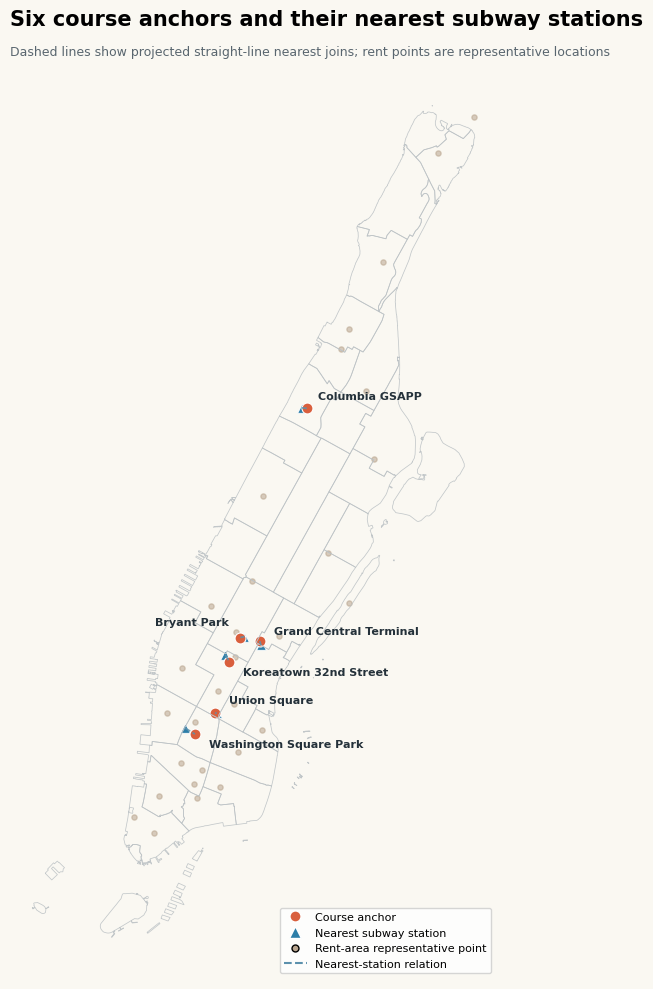

In [5]:
station_geometry = subway.drop_duplicates("stop_id").set_index("stop_id").geometry
connector_lines = gpd.GeoDataFrame(
    {
        "place_id": enriched["place_id"],
        "geometry": [
            LineString([row.geometry, station_geometry.loc[row.stop_id]])
            for row in enriched.itertuples()
        ],
    },
    crs=PROJECTED_CRS,
)
selected_stations = subway[subway.stop_id.isin(enriched.stop_id)].drop_duplicates("stop_id")

fig, ax = plt.subplots(figsize=(9, 10), facecolor="#faf8f2")
ax.set_facecolor("#faf8f2")
nta.boundary.plot(ax=ax, color="#bcc2c5", linewidth=0.55, alpha=0.9)
rent.plot(ax=ax, color="#b9a58f", markersize=14, alpha=0.55)
connector_lines.plot(ax=ax, color="#5c91ad", linewidth=1.25, linestyle="--", alpha=0.85)
selected_stations.plot(ax=ax, color="#2d7ea8", marker="^", markersize=48, edgecolor="white", linewidth=0.6)
enriched.plot(ax=ax, color="#d95f3d", markersize=62, edgecolor="white", linewidth=0.8)

label_layout = {
    "Columbia GSAPP": ((8, 7), "left"),
    "Bryant Park": ((-8, 9), "right"),
    "Grand Central Terminal": ((10, 5), "left"),
    "Koreatown 32nd Street": ((10, -10), "left"),
    "Union Square": ((10, 7), "left"),
    "Washington Square Park": ((10, -9), "left"),
}
for row in enriched.itertuples():
    label_offset, horizontal_alignment = label_layout.get(
        row.label, ((5, 5), "left")
    )
    ax.annotate(
        row.label,
        (row.geometry.x, row.geometry.y),
        xytext=label_offset,
        textcoords="offset points",
        ha=horizontal_alignment,
        fontsize=8,
        weight="semibold",
        color="#24313a",
    )

ax.set_title(
    "Six course anchors and their nearest subway stations",
    loc="left",
    fontsize=15,
    weight="bold",
    pad=28,
)
ax.text(
    0,
    1.01,
    "Dashed lines show projected straight-line nearest joins; rent points are representative locations",
    transform=ax.transAxes,
    fontsize=9,
    color="#59666f",
)
ax.legend(
    handles=[
        Line2D([0], [0], marker="o", color="none", markerfacecolor="#d95f3d", markeredgecolor="white", markersize=8, label="Course anchor"),
        Line2D([0], [0], marker="^", color="none", markerfacecolor="#2d7ea8", markeredgecolor="white", markersize=8, label="Nearest subway station"),
        Line2D([0], [0], marker="o", color="none", markerfacecolor="#b9a58f", markersize=5, label="Rent-area representative point"),
        Line2D([0], [0], color="#5c91ad", linestyle="--", label="Nearest-station relation"),
    ],
    loc="lower right",
    frameon=True,
    fontsize=8,
)
ax.set_axis_off()
fig.tight_layout()

plt.show()
plt.close(fig)

## 6. Workflow

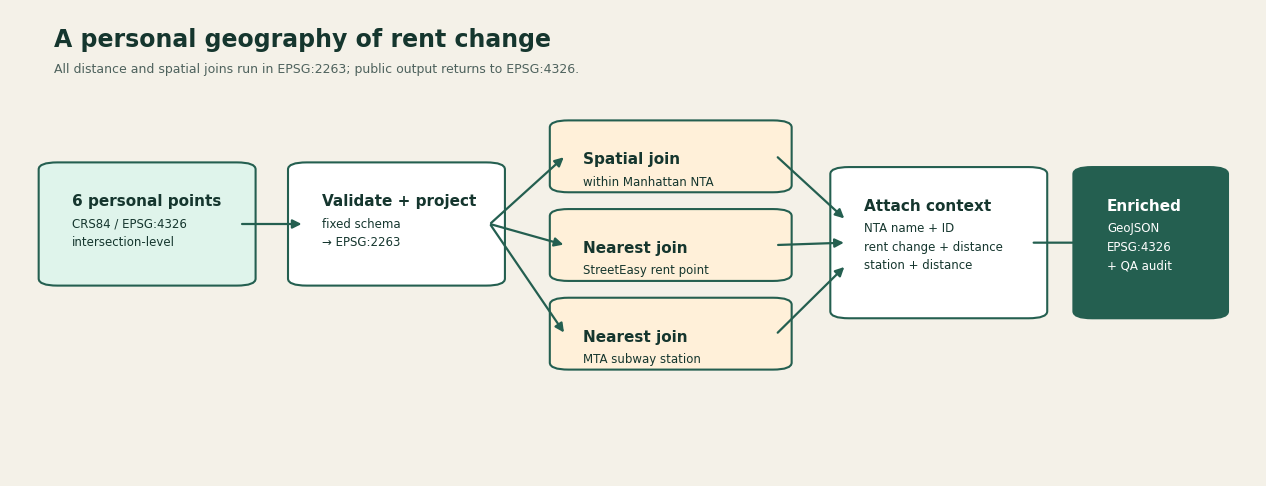

In [6]:
workflow_fig, workflow_ax = plt.subplots(figsize=(12.8, 5), facecolor="#f4f1e8")
workflow_ax.set_facecolor("#f4f1e8")
workflow_ax.set_xlim(0, 1)
workflow_ax.set_ylim(0, 1)
workflow_ax.set_axis_off()


def workflow_box(
    x,
    y,
    width,
    height,
    title,
    details,
    *,
    facecolor="#ffffff",
    text_color="#15362e",
):
    workflow_ax.add_patch(
        FancyBboxPatch(
            (x, y),
            width,
            height,
            boxstyle="round,pad=0.012,rounding_size=0.015",
            linewidth=1.5,
            edgecolor="#245f50",
            facecolor=facecolor,
        )
    )
    workflow_ax.text(
        x + 0.015,
        y + height - 0.055,
        title,
        ha="left",
        va="top",
        fontsize=11,
        fontweight="bold",
        color=text_color,
    )
    workflow_ax.text(
        x + 0.015,
        y + height - 0.105,
        details,
        ha="left",
        va="top",
        fontsize=8.5,
        linespacing=1.55,
        color=text_color,
    )


def workflow_arrow(start, end, *, connectionstyle="arc3"):
    workflow_ax.add_patch(
        FancyArrowPatch(
            start,
            end,
            arrowstyle="-|>",
            mutation_scale=13,
            linewidth=1.6,
            color="#245f50",
            connectionstyle=connectionstyle,
            shrinkA=1,
            shrinkB=1,
        )
    )


workflow_ax.text(
    0.035,
    0.92,
    "A personal geography of rent change",
    fontsize=17,
    fontweight="bold",
    color="#15362e",
)
workflow_ax.text(
    0.035,
    0.865,
    "All distance and spatial joins run in EPSG:2263; public output returns to EPSG:4326.",
    fontsize=9,
    color="#4e625d",
)

workflow_box(
    0.035, 0.42, 0.15, 0.24,
    "6 personal points", "CRS84 / EPSG:4326\nintersection-level",
    facecolor="#dff4eb",
)
workflow_box(
    0.235, 0.42, 0.15, 0.24,
    "Validate + project", "fixed schema\n→ EPSG:2263",
)
workflow_box(
    0.445, 0.62, 0.17, 0.13,
    "Spatial join", "within Manhattan NTA",
    facecolor="#fff0d9",
)
workflow_box(
    0.445, 0.43, 0.17, 0.13,
    "Nearest join", "StreetEasy rent point",
    facecolor="#fff0d9",
)
workflow_box(
    0.445, 0.24, 0.17, 0.13,
    "Nearest join", "MTA subway station",
    facecolor="#fff0d9",
)
workflow_box(
    0.67, 0.35, 0.15, 0.30,
    "Attach context", "NTA name + ID\nrent change + distance\nstation + distance",
)
workflow_box(
    0.865, 0.35, 0.10, 0.30,
    "Enriched", "GeoJSON\nEPSG:4326\n+ QA audit",
    facecolor="#245f50",
    text_color="#ffffff",
)

workflow_arrow((0.185, 0.54), (0.235, 0.54))
workflow_arrow((0.385, 0.54), (0.445, 0.685))
workflow_arrow((0.385, 0.54), (0.445, 0.495))
workflow_arrow((0.385, 0.54), (0.445, 0.305))
workflow_arrow((0.615, 0.685), (0.67, 0.55))
workflow_arrow((0.615, 0.495), (0.67, 0.50))
workflow_arrow((0.615, 0.305), (0.67, 0.45))
workflow_arrow((0.82, 0.50), (0.865, 0.50))

workflow_fig.tight_layout(pad=1.2)
plt.show()
plt.close(workflow_fig)

## 7. Validate the committed handoff

In [7]:
committed = gpd.read_file(OUTPUT_DIR / "personal_places_enriched.geojson").sort_values("place_id")
comparison_columns = [
    "place_id", "nta_name", "rent_area_id", "growth_pct", "stop_id", "subway_distance_m"
]
pd.testing.assert_frame_equal(
    enriched[comparison_columns].reset_index(drop=True),
    committed[comparison_columns].reset_index(drop=True),
    check_dtype=False,
    rtol=1e-6,
    atol=1e-6,
)

checks = pd.Series({
    "six input points": len(places) == 6,
    "six unique output rows": len(enriched) == 6 and enriched.place_id.is_unique,
    "all points inside Manhattan NTA coverage": not outside.any(),
    "no missing NTA joins": enriched.nta_name.notna().all(),
    "no missing rent-area joins": enriched.rent_area_name.notna().all(),
    "no missing subway joins": enriched.nearest_subway_station.notna().all(),
    "notebook result matches committed GeoJSON": True,
    "no precise-address fields": not forbidden_fields.intersection(places.columns),
}, name="passed")
assert checks.all()
display(checks.to_frame())
print(
    f"Nearest-subway distances range from {enriched.subway_distance_m.min():.1f} "
    f"to {enriched.subway_distance_m.max():.1f} meters."
)

,passed
six input points,True
six unique output rows,True
all points inside Manhattan NTA coverage,True
no missing NTA joins,True
no missing rent-area joins,True
no missing subway joins,True
notebook result matches committed GeoJSON,True
no precise-address fields,True


Nearest-subway distances range from 45.4 to 316.1 meters.


## Takeaways and limits

- The workflow demonstrates a complete projected point-in-polygon and nearest-neighbor pipeline, with one deterministic output row per input point.
- A nearby rent-area representative point does not mean that its asking-rent value applies precisely at the course anchor. It is a reporting-area proxy.
- A nearest station point is not necessarily the shortest entrance-to-entrance walk. Assignment 04 replaces this straight-line relation with a pedestrian-network analysis.
- These six public anchors form a privacy-safe coursework narrative. Replacing them with private addresses would add risk without improving the geoprocessing method.